In [ ]:
# tried running it on my own gpu but it was still slow - this just checks your local gpu
# !nvidia-smi

Sun May  4 18:41:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   40C    P8              5W /   65W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
# imstall these required packagess once
# !pip install -q kaggle
# !pip install -q nltk
# !pip install -q tqdm
!pip install tensorflow



# Imports
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# only use when working using gpu of google
import kagglehub
from google.colab import files
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,  Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix


print('imports done!')

imports done!


In [2]:
# loading the dataset of facial expressions from kaggle !


path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files: ", path)
print("Contents of dataset directory:")
print(os.listdir(path))

# path = r"C:\Users\cai\Documents\6th Semester - Spring 2025\Deep Learning\Project\ferdataset"

# print("Path to dataset files:", path)
# print("Contents of dataset directory:")
# print(os.listdir(path))

# image paths for the dataset
train_dir = os.path.join(path, "train")
val_dir = os.path.join(path, "test")

Path to dataset files:  /kaggle/input/fer2013
Contents of dataset directory:
['test', 'train']


In [3]:
# since ResNet expects images of size 224x224 RGB we have to resize & normalize!
# do for training and test dataset

# preprocessing data by resizing, normalizing and audmenting the data

image_size = (224, 224)
batch_size = 32

# do data augmentation to the training set for better generalization - this way it wont be dependent on exact inputs
# so we add trasnformations such as rotation, zoom, rescale etc.

train_datagenerator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# training set
train_generator = train_datagenerator.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical'
)

# validation set
val_generator = train_datagenerator.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# **Parameter Training to find the Best Parameters to Train with !**
DO NOT RUN THIS!!! THIS IS DONEEEEEEE
Note: This ran for 5hrs

#** DO NOT RUN THIS!**

In [ ]:
# Grid search values
etas = [1e-5, 1e-4, 1e-3]
epochs_list = [5, 10, 15]

# Best tracking
best_val_acc = 0.0
best_model = None
best_eta = None
best_epochs = None

for eta in etas:
    for n_epochs in epochs_list:

        print(f"Training model with learning rate = {eta}, epochs = {n_epochs}")

        # Build model
        base_res_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_res_model.trainable = False

        x = base_res_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(0.5)(x)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.3)(x)
        predictions = Dense(train_generator.num_classes, activation='softmax')(x)

        model = Model(inputs=base_res_model.input, outputs=predictions)

        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=eta),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train
        early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=0)
        history = model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=n_epochs,
            callbacks=[early_stop],
            verbose=1
        )

        # Check performance
        val_acc = max(history.history['val_accuracy'])
        print(f"Validation Accuracy: {val_acc:.4f}")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model
            best_eta = eta
            best_epochs = n_epochs
            print("New best model found!")


# make sure to save best model
best_model.save("best_facial_expression_model.keras")
print("\nBest Model Summary:")
print(f"Best Learning Rate: {best_eta}")
print(f"Best Number of Epochs: {best_epochs}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("Model saved as 'best_facial_expression_model.keras'")

# Download from google colab to my laptop - i do this bcs it doesnt show up sometimes in google collab's temp contents folder
# from google.colab import files
# files.download("best_facial_expression_model.keras")

model.save("best_facial_expression_model.keras")
print("Saved to current directory")


Training model with learning rate = 1e-05, epochs = 5
Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 526s 556ms/step - accuracy: 0.1426 - loss: 2.5028 - val_accuracy: 0.2471 - val_loss: 1.8472
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 489s 544ms/step - accuracy: 0.1901 - loss: 2.0602 - val_accuracy: 0.2470 - val_loss: 1.8486
Epoch 3/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 491s 547ms/step - accuracy: 0.1964 - loss: 1.9800 - val_accuracy: 0.2473 - val_loss: 1.8381
Epoch 4/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 490s 545ms/step - accuracy: 0.1995 - loss: 1.9402 - val_accuracy: 0.2473 - val_loss: 1.8288
Epoch 5/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 482s 536ms/step - accuracy: 0.1976 - loss: 1.9106 - val_accuracy: 0.2471 - val_loss: 1.8325
Validation Accuracy: 0.2473
New best model found!
Training model with learning rate = 1e-05, epochs = 10
Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 549s 600ms/step - accuracy: 0.1894 - loss: 2.3924 - val_accuracy: 0.1335 - val_loss: 1.8765
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 493s 549ms/ste

In [ ]:
# Grid search values continued
etas = [1e-4, 1e-3]
epochs_list = [5, 10, 15]

# Best tracking
best_val_acc = 0.0
best_model = None
best_eta = None
best_epochs = None

for eta in etas:
    for n_epochs in epochs_list:

        if eta == 1e-4 and (n_epochs == 5 or n_epochs == 10):
          continue

        print(f"Training model with learning rate = {eta}, epochs = {n_epochs}")

        # Build model
        base_res_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_res_model.trainable = False

        x = base_res_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(0.5)(x)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.3)(x)
        predictions = Dense(train_generator.num_classes, activation='softmax')(x)

        model = Model(inputs=base_res_model.input, outputs=predictions)

        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=eta),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train
        early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=0)
        history = model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=n_epochs,
            callbacks=[early_stop],
            verbose=1
        )

        # Check performance
        val_acc = max(history.history['val_accuracy'])
        print(f"Validation Accuracy: {val_acc:.4f}")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model
            best_eta = eta
            best_epochs = n_epochs
            print("New best model found!")


# make sure to save best model
best_model.save("best_facial_expression_model.keras")
print("\nBest Model Summary:")
print(f"Best Learning Rate: {best_eta}")
print(f"Best Number of Epochs: {best_epochs}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("Model saved as 'best_facial_expression_model.keras'")

# Download from google colab to my laptop - i do this bcs it doesnt show up sometimes in google collab's temp contents folder
# from google.colab import files
# files.download("best_facial_expression_model.keras")

model.save("best_facial_expression_model.keras")
print("Saved to current directory")

Training model with learning rate = 0.0001, epochs = 15
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 655s 711ms/step - accuracy: 0.1994 - loss: 2.0453 - val_accuracy: 0.1718 - val_loss: 1.8646
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 515s 573ms/step - accuracy: 0.2209 - loss: 1.8538 - val_accuracy: 0.2471 - val_loss: 1.8404
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 575s 587ms/step - accuracy: 0.2317 - loss: 1.8377 - val_accuracy: 0.2471 - val_loss: 1.8338
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 501s 558ms/step - accuracy: 0.2384 - loss: 1.8322 - val_accuracy: 0.2471 - val_loss: 1.8240
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 500s 557ms/step - accuracy: 0.2485 - loss: 1.8279 - val_accuracy: 0.2471 - val_loss: 1.8193
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 495s 551ms/step - accuracy: 0.2493 - loss: 1.8203 - val_accuracy: 0.2471 - val_loss: 1.8147
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 502s 551ms/step - accuracy: 0.2456 - loss: 1.8253 - val_accuracy: 0.2471 - val_loss: 1.8156
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 500s 557ms/step - accuracy: 0.2503 -

In [ ]:
from google.colab import files
files.download("best_facial_expression_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Throughout the parameter testing, it can be observed that the validation accuracy would go down after reaching a point which may be Plateauing / its nearing convergence or batches have too much noise.

But! the accuracy was stable-y imporving showing that it didnt plateu completely meaning it will still generalize well. this is where early stopping helped us - it would stop the epoch when there is a drop in accuracy or is barely improving

this shows us that we still need to fine tune it:
we will try:
  
*   Fine tune lower levels of the pretrained model - right now were only doing the last layer
*   We will compare it to another model EfficientNetB0





# **Plug in the Best Parameters found and Fine Tune the more !**

were gonna unfreeze some of the deeper layers of this pretrained model using the best params weve taken from the training above

In [ ]:
# ResNet Transfer Layer Model! (starting Transfer Learning)
# we chose this because its already pretrained with imagenet - only planning to train the last layer
# faster and more efficient for our project

# well use Adam Optimizer in ResNet 50

# ------ This code was the very first trial which I based the grid search and fine tuning from --------------

# loading ResNet50 w/o last layer then we freeze!
base_res_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_res_model.trainable = False

# should we do avgpooling or maxpooling???? idk yettt

x = base_res_model.output
x = GlobalAveragePooling2D()(x)
# x = MaxPooling2D(pool_size=(7, 7))(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# build & save the model !!
model = Model(inputs=base_res_model.input, outputs=predictions)

# Compile it
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()



In [ ]:
# unfreezing and doing further finetuning !

np.random.seed(42)
tf.random.set_seed(42)

# === Phase 1: Build model with frozen base ===
base_res_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_res_model.trainable = False  # freeze all layers

# Add classification head
x = base_res_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# Build the model
model = Model(inputs=base_res_model.input, outputs=predictions)

# Compile with BEST PARAMS found (frozen)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Phase 1 training
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print("Phase 1: Training top layers only...")
history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping],
    verbose=1
)

model.save("phase1_trained_model.keras")
print("Phase 1 model saved!")
files.download("phase1_finetuned_facial_expression_model.keras")



Phase 1: Training top layers only...
Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 571s 624ms/step - accuracy: 0.2246 - loss: 1.8893 - val_accuracy: 0.2471 - val_loss: 1.8141
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 440s 490ms/step - accuracy: 0.2490 - loss: 1.8197 - val_accuracy: 0.2471 - val_loss: 1.8110
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 435s 485ms/step - accuracy: 0.2580 - loss: 1.8126 - val_accuracy: 0.2471 - val_loss: 1.8179
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 437s 487ms/step - accuracy: 0.2505 - loss: 1.8139 - val_accuracy: 0.2471 - val_loss: 1.8070
Epoch 5/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 438s 488ms/step - accuracy: 0.2544 - loss: 1.8115 - val_accuracy: 0.2471 - val_loss: 1.8074
Epoch 6/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 441s 491ms/step - accuracy: 0.2555 - loss: 1.8096 - val_accuracy: 0.2471 - val_loss: 1.8085
Epoch 7/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 437s 486ms/step - accuracy: 0.2477 - loss: 1.8133 - val_accuracy: 0.2474 - val_loss: 1.8043
Epoch 8/15
898/898 ━━━━━━━━━━━━━━━━━━━━

In [5]:
from google.colab import files
files.download("best_param_gridsearch_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from tensorflow.keras.models import load_model
base_res_model = load_model("best_param_gridsearch_model.keras")

In [11]:
# === Phase 2: Fine-tune deeper layers ===
# Unfreeze top 30 layers of ResNet
for layer in base_res_model.layers[-30:]:
    layer.trainable = True

# Re-compile with lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Phase 2 training
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print("Phase 2: Fine-tuning top 30 layers...")
history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping],
    verbose=1
)


Phase 2: Fine-tuning top 30 layers...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 605s 661ms/step - accuracy: 0.2462 - loss: 1.8062 - val_accuracy: 0.2478 - val_loss: 1.7994
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 477s 532ms/step - accuracy: 0.2486 - loss: 1.8068 - val_accuracy: 0.2484 - val_loss: 1.8002
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 519s 578ms/step - accuracy: 0.2548 - loss: 1.8028 - val_accuracy: 0.2485 - val_loss: 1.7997
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 469s 522ms/step - accuracy: 0.2478 - loss: 1.8049 - val_accuracy: 0.2494 - val_loss: 1.7996
Phase 2 model saved!


FileNotFoundError: Cannot find file: phase2_finetuned_facial_expression_model.keras

In [12]:
# Save fine-tuned model
model.save("phase2_trained_model.keras")
print("Phase 2 model saved!")
files.download("phase2_trained_model.keras")

Phase 2 model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# import tensorflow as tf
# import numpy as np

# Optional: Set seed for reproducibility
# np.random.seed(42)
# tf.random.set_seed(42)

# Load the saved model from Phase 1
# model = load_model("/content/phase1_trained_model.keras")

In [14]:
# doing early stopping so that it stops training when the valdation loss stops improving
# early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

train the model
history = model.fit(
   train_generator,
   validation_data=val_generator,
   epochs=10,
   callbacks=[early_stopping]
)

# Save the model to a file
# model.save('facial_exp_resnet50_model.keras')  #Will create a directory that has all the related files and saves everything there

# files.download("facial_exp_resnet50_model.keras")
# saved_model = tf.keras.models.load_model('facial_exp_resnet50_model.keras')
# score = saved_model.evaluate(val_generator)

# print("Testing Loss:", score[0], "Testing Accuracy:", score[1])
# print("Model saved as 'facial_expression_resnet_model'")

In [ ]:
loss, accuracy = model.evaluate(val_generator)
print(f"✅ Test Loss: {loss:.4f}")
print(f"✅ Test Accuracy: {accuracy:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 96s 427ms/step - accuracy: 0.1829 - loss: 1.8199
✅ Test Loss: 1.8291
✅ Test Accuracy: 0.1797


In [ ]:
# converts softmax probabilities to class labels!
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

model = load_model("/content/best_facial_expression_model.keras")
# Predict probabilities
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_generator.classes

# Class labels
class_labels = list(val_generator.class_indices.keys())

# Classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

In [ ]:

# 2. Set your class labels (same order as during training)
class_labels = list(val_generator.class_indices.keys())

# 3. Load and preprocess your image
img_path = "/content/boy.jpg"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0  # normalize
img_array = np.expand_dims(img_array, axis=0)  # batch shape

# 4. Predict
pred = model.predict(img_array)
pred_class = class_labels[np.argmax(pred)]

print(f"Predicted Expression: {pred_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Expression: happy


In [18]:
import matplotlib.pyplot as plt

def plot_history(history, title='Model'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Train Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

#plot_history(history_phase1, title='ResNet50 Phase 1')
#plot_history(history_phase2, title='ResNet50 Phase 2')

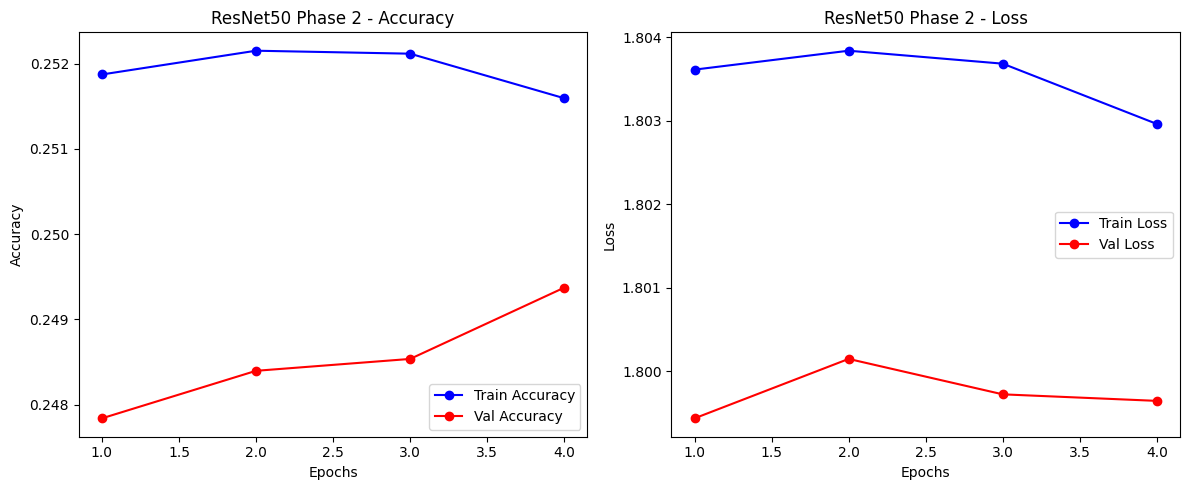

In [19]:
plot_history(history_phase2, title='ResNet50 Phase 2')

225/225 ━━━━━━━━━━━━━━━━━━━━ 104s 462ms/step


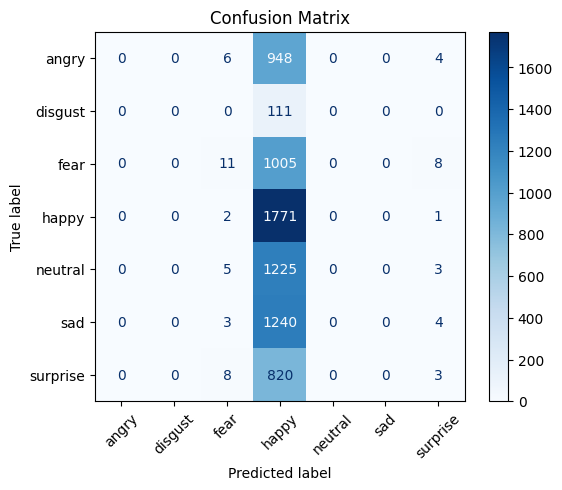

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# True and predicted labels
y_true = val_generator.classes
y_pred = np.argmax(model.predict(val_generator), axis=1)
class_labels = list(val_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


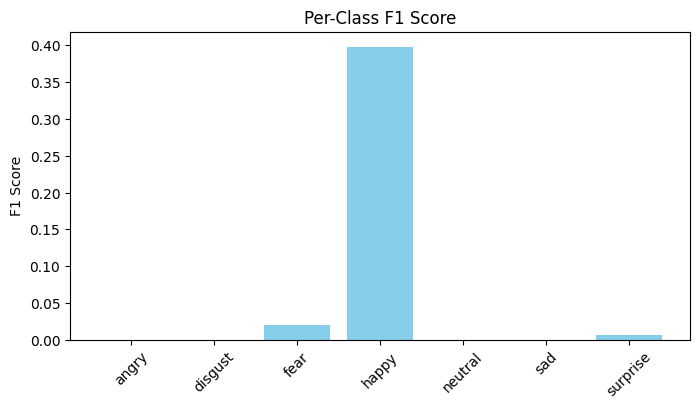

In [20]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
f1_scores = [report[label]['f1-score'] for label in class_labels]

plt.figure(figsize=(8,4))
plt.bar(class_labels, f1_scores, color='skyblue')
plt.title("Per-Class F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # True and predicted labels
# y_true = val_generator.classes
# y_pred = np.argmax(model.predict(val_generator), axis=1)
# class_labels = list(val_generator.class_indices.keys())

# # Confusion matrix
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
# disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
# plt.title("Confusion Matrix")
# plt.show()

In [ ]:
# from sklearn.metrics import classification_report

# report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
# f1_scores = [report[label]['f1-score'] for label in class_labels]

# plt.figure(figsize=(8, 4))
# plt.bar(class_labels, f1_scores, color='skyblue')
# plt.title("Per-Class F1 Score")
# plt.ylabel("F1 Score")
# plt.xticks(rotation=45)
# plt.show()